In [ ]:
# Trash Detection and Segmentation using YOLO and U-Net

This project applies computer vision techniques to the TACO dataset to perform:

- Object detection using YOLO
- Image segmentation using U-Net

The goal is to explore detection and segmentation approaches for real-world trash recognition.

In [21]:
# ============================================================================
# CELL 3 — DATASET PATHS (LOCAL PC - VOLUME E)
# ============================================================================

BASE_PATH = r"E:\coding stuff (datasets)\taco trash dataset"

ANNOTATIONS_PATH = os.path.join(BASE_PATH, "data", "annotations.json")
IMAGES_PATH = os.path.join(BASE_PATH, "data")

YOLO_BASE = os.path.join(BASE_PATH, "yolo_data")

print("Annotations exists:", os.path.exists(ANNOTATIONS_PATH))
print("Images folder exists:", os.path.exists(IMAGES_PATH))

# Make YOLO directories
os.makedirs(YOLO_BASE, exist_ok=True)
os.makedirs(os.path.join(YOLO_BASE, "images", "train"), exist_ok=True)
os.makedirs(os.path.join(YOLO_BASE, "images", "val"), exist_ok=True)
os.makedirs(os.path.join(YOLO_BASE, "labels", "train"), exist_ok=True)
os.makedirs(os.path.join(YOLO_BASE, "labels", "val"), exist_ok=True)


Annotations exists: True
Images folder exists: True


In [23]:
coco = COCO(ANNOTATIONS_PATH)

print("\nTotal categories:", len(coco.cats))
print("Total images:", len(coco.imgs))
print("Total annotations:", len(coco.anns))

print("\nFirst 10 categories:")
for i, c in list(coco.cats.items())[:10]:
    print(f"ID: {c['id']}, Name: {c['name']}")


loading annotations into memory...
Done (t=0.08s)
creating index...
index created!

Total categories: 60
Total images: 1500
Total annotations: 4782

First 10 categories:
ID: 0, Name: Aluminium foil
ID: 1, Name: Battery
ID: 2, Name: Aluminium blister pack
ID: 3, Name: Carded blister pack
ID: 4, Name: Other plastic bottle
ID: 5, Name: Clear plastic bottle
ID: 6, Name: Glass bottle
ID: 7, Name: Plastic bottle cap
ID: 8, Name: Metal bottle cap
ID: 9, Name: Broken glass


In [25]:
cat_counts = {}

for ann_id, ann in coco.anns.items():
    cid = ann['category_id']
    cat_counts[cid] = cat_counts.get(cid, 0) + 1

sorted_counts = sorted(cat_counts.items(), key=lambda x: x[1], reverse=True)

top_5_ids = [c[0] for c in sorted_counts[:5]]
print("Top 5 category IDs:", top_5_ids)

print("\nTop 5 category names:")
for cid in top_5_ids:
    print(coco.cats[cid]["name"])


Top 5 category IDs: [59, 58, 36, 5, 29]

Top 5 category names:
Cigarette
Unlabeled litter
Plastic film
Clear plastic bottle
Other plastic


In [27]:
print("Filtering dataset for top 5 classes...")

filtered_img_ids = []
for img_id, img in coco.imgs.items():
    ann_ids = coco.getAnnIds(imgIds=[img_id], catIds=top_5_ids)
    if len(ann_ids) > 0:
        filtered_img_ids.append(img_id)

print(f"Filtered images: {len(filtered_img_ids)} out of {len(coco.imgs)}")


Filtering dataset for top 5 classes...
Filtered images: 861 out of 1500


In [29]:
cat_id_mapping = {cid: idx for idx, cid in enumerate(top_5_ids)}
cat_id_mapping


{59: 0, 58: 1, 36: 2, 5: 3, 29: 4}

In [35]:
random.shuffle(filtered_img_ids)

split_idx = int(0.8 * len(filtered_img_ids))
train_ids = filtered_img_ids[:split_idx]
val_ids = filtered_img_ids[split_idx:]

print("Train images:", len(train_ids))
print("Val images:", len(val_ids))


Train images: 688
Val images: 173


In [37]:
def save_yolo_format(img_ids, split):
    img_dir = os.path.join(YOLO_BASE, "images", split)
    lbl_dir = os.path.join(YOLO_BASE, "labels", split)

    for img_id in img_ids:
        img_info = coco.loadImgs([img_id])[0]
        img_name = img_info["file_name"]        # includes 'batch_XX/...'
        
        # Create batch subfolder under images and labels
        subfolder = os.path.dirname(img_name)   # e.g., 'batch_13'
        os.makedirs(os.path.join(img_dir, subfolder), exist_ok=True)
        os.makedirs(os.path.join(lbl_dir, subfolder), exist_ok=True)

        # full source path
        src = os.path.join(IMAGES_PATH, img_name)
        dst = os.path.join(img_dir, img_name)
        shutil.copy(src, dst)

        # Load annotations
        ann_ids = coco.getAnnIds(imgIds=[img_id], catIds=top_5_ids)
        anns = coco.loadAnns(ann_ids)

        img_w, img_h = img_info["width"], img_info["height"]

        # label file must also be inside batch_xx/
        lab_path = os.path.join(lbl_dir, img_name.replace(".jpg", ".txt"))
        lines = []

        for ann in anns:
            cid = ann["category_id"]
            if cid not in top_5_ids:
                continue

            mapped = cat_id_mapping[cid]
            x, y, w, h = ann["bbox"]

            xc = (x + w/2) / img_w
            yc = (y + h/2) / img_h
            wn = w / img_w
            hn = h / img_h

            lines.append(f"{mapped} {xc} {yc} {wn} {hn}\n")

        with open(lab_path, "w") as f:
            f.writelines(lines)

    print(f"{split} YOLO conversion complete!")


In [39]:
save_yolo_format(train_ids, "train")
save_yolo_format(val_ids, "val")


train YOLO conversion complete!
val YOLO conversion complete!


Top 5 categories: ['Cigarette', 'Unlabeled litter', 'Plastic film', 'Clear plastic bottle', 'Other plastic']


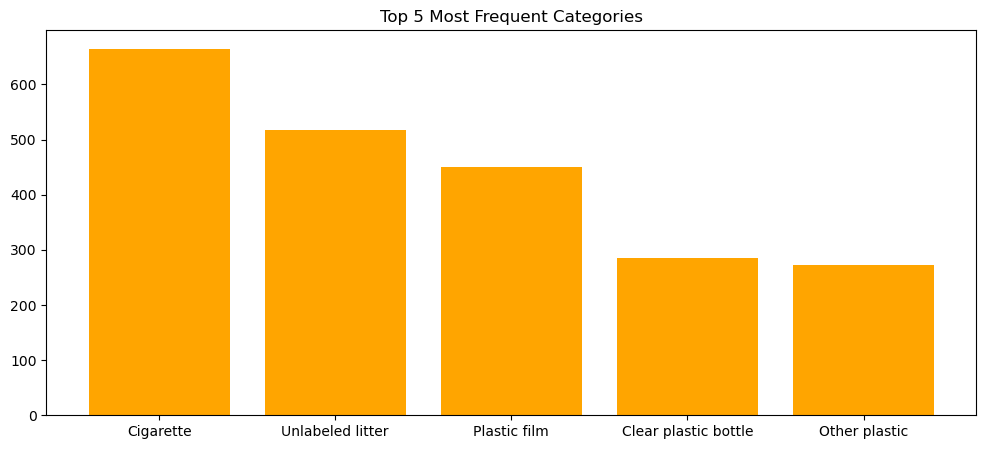

In [41]:
#Category distribution plot
ann_ids = coco.getAnnIds()
anns = coco.loadAnns(ann_ids)

cat_count = {}
for ann in anns:
    cid = ann['category_id']
    cat_count[cid] = cat_count.get(cid, 0) + 1

sorted_counts = sorted(cat_count.items(), key=lambda x: x[1], reverse=True)

top_5_ids = [cid for cid, _ in sorted_counts[:5]]
top_5_names = [coco.loadCats([cid])[0]['name'] for cid in top_5_ids]

print("Top 5 categories:", top_5_names)

plt.figure(figsize=(12,5))
plt.bar(top_5_names, [cat_count[cid] for cid in top_5_ids], color='orange')
plt.title("Top 5 Most Frequent Categories")
plt.show()


Text(0.5, 1.0, 'Example Image')

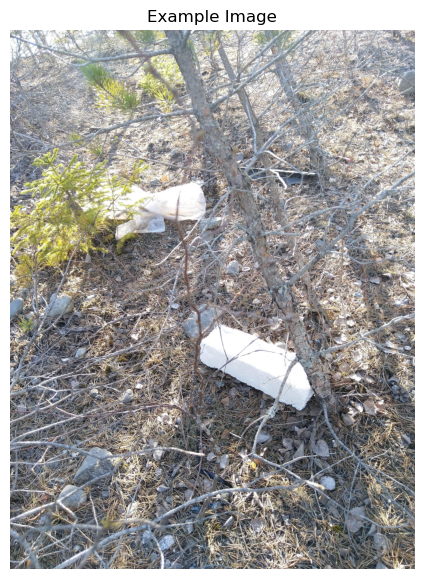

In [43]:
#Example images and boxes for top 5 cuts
import random

example_img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs([example_img_id])[0]
anns = coco.loadAnns(coco.getAnnIds(imgIds=[example_img_id]))

img_path = os.path.join(IMAGES_PATH, img_info['file_name'])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,7))
plt.imshow(img)
plt.axis("off")
plt.title("Example Image")



In [45]:
print("Top 5 category IDs:", top_5_ids)
cat_id_mapping = {cid: idx for idx, cid in enumerate(top_5_ids)}
print("Re-mapped YOLO class IDs:", cat_id_mapping)


Top 5 category IDs: [59, 58, 36, 5, 29]
Re-mapped YOLO class IDs: {59: 0, 58: 1, 36: 2, 5: 3, 29: 4}


In [47]:
filtered_img_ids = []
for img_id in coco.getImgIds():
    ann_ids = coco.getAnnIds(imgIds=[img_id], catIds=top_5_ids)
    if len(ann_ids) > 0:
        filtered_img_ids.append(img_id)

print("Images with top-5 categories:", len(filtered_img_ids))


Images with top-5 categories: 861


In [49]:
random.shuffle(filtered_img_ids)
split = int(0.8 * len(filtered_img_ids))

train_ids = filtered_img_ids[:split]
val_ids   = filtered_img_ids[split:]

print("Train images:", len(train_ids))
print("Val images:", len(val_ids))


Train images: 688
Val images: 173


In [53]:
def save_yolo(split_ids, split):
    img_dir = os.path.join(YOLO_BASE, "images", split)
    lbl_dir = os.path.join(YOLO_BASE, "labels", split)

    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    for img_id in split_ids:
        img_info = coco.loadImgs([img_id])[0]
        img_name = img_info["file_name"]          # e.g. 'batch_11/000076.jpg'

        # ✅ Correct source path (no duplicate batch folder)
        src_path = os.path.join(IMAGES_PATH, img_name)  # data/batch_11/000076.jpg

        # Make sure subfolders (batch_xx) exist under images/ and labels/
        subfolder = os.path.dirname(img_name)           # 'batch_11'
        os.makedirs(os.path.join(img_dir, subfolder), exist_ok=True)
        os.makedirs(os.path.join(lbl_dir, subfolder), exist_ok=True)

        # Copy image into yolo_data/images/split/batch_xx/000076.jpg
        dst_path = os.path.join(img_dir, img_name)
        shutil.copy(src_path, dst_path)

        # Annotations
        ann_ids = coco.getAnnIds(imgIds=[img_id], catIds=top_5_ids)
        anns = coco.loadAnns(ann_ids)
        w, h = img_info["width"], img_info["height"]

        # Label file path mirrors the same relative structure
        label_rel = img_name.replace(".jpg", ".txt")
        label_file = os.path.join(lbl_dir, label_rel)

        lines = []
        for ann in anns:
            cid = ann["category_id"]
            if cid not in top_5_ids:
                continue

            class_id = cat_id_mapping[cid]
            x, y, bw, bh = ann["bbox"]   # COCO: x,y,w,h

            xc = (x + bw / 2) / w
            yc = (y + bh / 2) / h
            wn = bw / w
            hn = bh / h

            lines.append(f"{class_id} {xc} {yc} {wn} {hn}\n")

        # Make sure label subfolder exists
        os.makedirs(os.path.dirname(label_file), exist_ok=True)
        with open(label_file, "w") as f:
            f.writelines(lines)

    print(f"{split} YOLO conversion complete!")
    

save_yolo(train_ids, "train")
save_yolo(val_ids, "val")


train YOLO conversion complete!
val YOLO conversion complete!


In [55]:
# ============================================================================
# CELL 11: Create YOLO data.yaml (Local Windows version)
# ============================================================================

import yaml
import os

yaml_path = os.path.join(YOLO_BASE, "data.yaml")

data_yaml = {
    "path": YOLO_BASE,
    "train": "images/train",
    "val": "images/val",
    "nc": 5,
    "names": top_5_names
}

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created successfully!")
print("----")
print(open(yaml_path).read())


data.yaml created successfully!
----
names:
- Cigarette
- Unlabeled litter
- Plastic film
- Clear plastic bottle
- Other plastic
nc: 5
path: E:\coding stuff (datasets)\taco trash dataset\yolo_data
train: images/train
val: images/val



In [61]:
#fixing shi
!pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.7.0+cu118
Uninstalling torch-2.7.0+cu118:
  Successfully uninstalled torch-2.7.0+cu118
Found existing installation: torchvision 0.22.0+cu118
Uninstalling torchvision-0.22.0+cu118:
  Successfully uninstalled torchvision-0.22.0+cu118
Found existing installation: torchaudio 2.7.0+cu118
Uninstalling torchaudio-2.7.0+cu118:
  Successfully uninstalled torchaudio-2.7.0+cu118


You can safely remove it manually.
You can safely remove it manually.


In [67]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


2.7.0+cu118
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [73]:
from torch.serialization import add_safe_globals
import torch.nn as nn
from ultralytics.nn.tasks import DetectionModel

# Allow YOLO + PyTorch modules to load safely
add_safe_globals([
    DetectionModel,
    nn.Sequential,
    nn.Conv2d,
    nn.BatchNorm2d,
    nn.ReLU,
    nn.SiLU,
    nn.Module,
    nn.ConvTranspose2d,
    nn.Upsample,
    nn.MaxPool2d,
])

print("Safe globals added.")


Safe globals added.


In [79]:
!pip uninstall -y torch torchvision torchaudio ultralytics


Found existing installation: torch 2.3.0+cu121
Uninstalling torch-2.3.0+cu121:
  Successfully uninstalled torch-2.3.0+cu121
Found existing installation: torchvision 0.18.0+cu121
Uninstalling torchvision-0.18.0+cu121:
  Successfully uninstalled torchvision-0.18.0+cu121
Found existing installation: torchaudio 2.3.0+cu121
Uninstalling torchaudio-2.3.0+cu121:
  Successfully uninstalled torchaudio-2.3.0+cu121
Found existing installation: ultralytics 8.3.0
Uninstalling ultralytics-8.3.0:
  Successfully uninstalled ultralytics-8.3.0


In [3]:
#!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121


In [1]:
#!pip install ultralytics==8.3.0


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import shutil
import random

from pycocotools.coco import COCO
from ultralytics import YOLO

import torch
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


In [ ]:
#restarting shi again

In [1]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print("Model loaded successfully!")


Model loaded successfully!


In [3]:
import os
import json
import numpy as np
import pandas as pd
import shutil
import random

from pycocotools.coco import COCO
from ultralytics import YOLO

import torch
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.9.1+cpu
CUDA: False


In [5]:
!pip uninstall torch torchvision torchaudio -y
!pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.9.1
Uninstalling torch-2.9.1:
  Successfully uninstalled torch-2.9.1
Found existing installation: torchvision 0.24.1
Uninstalling torchvision-0.24.1:
  Successfully uninstalled torchvision-0.24.1
Found existing installation: torchaudio 2.4.0+cu121
Uninstalling torchaudio-2.4.0+cu121:
  Successfully uninstalled torchaudio-2.4.0+cu121


You can safely remove it manually.
You can safely remove it manually.


In [7]:
#!pip install torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


In [1]:
import torch
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.7.0+cu118
CUDA: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
 #doing shi again

In [3]:
import os
import json
import numpy as np
import pandas as pd
import shutil
import random

from pycocotools.coco import COCO
from ultralytics import YOLO

import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.7.0+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
# Base path where you unzipped the dataset
BASE_PATH = r"E:\coding stuff (datasets)\taco trash dataset"

# COCO annotations are inside data/annotations.json
ANNOTATIONS_PATH = os.path.join(BASE_PATH, "data", "annotations.json")

# Images live under data/batch_1, batch_2, ...
IMAGES_PATH = os.path.join(BASE_PATH, "data")

# YOLO output base (we create this)
YOLO_BASE = os.path.join(BASE_PATH, "yolo_data")

os.makedirs(YOLO_BASE, exist_ok=True)
os.makedirs(os.path.join(YOLO_BASE, "images", "train"), exist_ok=True)
os.makedirs(os.path.join(YOLO_BASE, "images", "val"), exist_ok=True)
os.makedirs(os.path.join(YOLO_BASE, "labels", "train"), exist_ok=True)
os.makedirs(os.path.join(YOLO_BASE, "labels", "val"), exist_ok=True)

print("BASE_PATH:", BASE_PATH)
print("ANNOTATIONS_PATH:", ANNOTATIONS_PATH)
print("IMAGES_PATH:", IMAGES_PATH)
print("YOLO_BASE:", YOLO_BASE)


BASE_PATH: E:\coding stuff (datasets)\taco trash dataset
ANNOTATIONS_PATH: E:\coding stuff (datasets)\taco trash dataset\data\annotations.json
IMAGES_PATH: E:\coding stuff (datasets)\taco trash dataset\data
YOLO_BASE: E:\coding stuff (datasets)\taco trash dataset\yolo_data


In [7]:
print("Loading COCO annotations...")
coco = COCO(ANNOTATIONS_PATH)

cats = coco.loadCats(coco.getCatIds())
cat_names = [c["name"] for c in cats]
cat_ids   = [c["id"]   for c in cats]

print(f"\nTotal categories: {len(cats)}")
print(f"Total images: {len(coco.getImgIds())}")
print(f"Total annotations: {len(coco.getAnnIds())}")

print("\nFirst 10 categories:")
for i, c in enumerate(cats[:10]):
    print(f"{i}. ID: {c['id']}, Name: {c['name']}")


Loading COCO annotations...
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!

Total categories: 60
Total images: 1500
Total annotations: 4784

First 10 categories:
0. ID: 0, Name: Aluminium foil
1. ID: 1, Name: Battery
2. ID: 2, Name: Aluminium blister pack
3. ID: 3, Name: Carded blister pack
4. ID: 4, Name: Other plastic bottle
5. ID: 5, Name: Clear plastic bottle
6. ID: 6, Name: Glass bottle
7. ID: 7, Name: Plastic bottle cap
8. ID: 8, Name: Metal bottle cap
9. ID: 9, Name: Broken glass


In [9]:
print("Counting category frequencies...")
ann_ids = coco.getAnnIds()
anns = coco.loadAnns(ann_ids)

freq = {}
for a in anns:
    cid = a["category_id"]
    freq[cid] = freq.get(cid, 0) + 1

# sort by frequency, descending
freq_sorted = sorted(freq.items(), key=lambda x: x[1], reverse=True)
top_5_ids   = [cid for cid, _ in freq_sorted[:5]]

print("Top 5 category IDs and counts:")
for cid, count in freq_sorted[:5]:
    name = coco.loadCats([cid])[0]["name"]
    print(f"ID {cid}: {name} -> {count} annotations")

TOP_5_CAT_IDS = top_5_ids  # keep name similar to old code


Counting category frequencies...
Top 5 category IDs and counts:
ID 59: Cigarette -> 665 annotations
ID 58: Unlabeled litter -> 518 annotations
ID 36: Plastic film -> 451 annotations
ID 5: Clear plastic bottle -> 286 annotations
ID 29: Other plastic -> 273 annotations


In [11]:
print("Filtering images that contain at least one of the top 5 classes...")

all_img_ids = coco.getImgIds()
filtered_img_ids = []

for img_id in all_img_ids:
    ann_ids = coco.getAnnIds(imgIds=[img_id], catIds=TOP_5_CAT_IDS)
    if len(ann_ids) > 0:
        filtered_img_ids.append(img_id)

print(f"Filtered images: {len(filtered_img_ids)} out of {len(all_img_ids)}")

# Train/val split (80/20)
random.seed(42)
random.shuffle(filtered_img_ids)

split_idx  = int(0.8 * len(filtered_img_ids))
train_ids  = filtered_img_ids[:split_idx]
val_ids    = filtered_img_ids[split_idx:]

print(f"Train images: {len(train_ids)}")
print(f"Val images: {len(val_ids)}")


Filtering images that contain at least one of the top 5 classes...
Filtered images: 861 out of 1500
Train images: 688
Val images: 173


In [13]:
cat_id_mapping = {cid: i for i, cid in enumerate(TOP_5_CAT_IDS)}
print("Category ID mapping:", cat_id_mapping)

print("\nMapped categories:")
for orig, mapped in cat_id_mapping.items():
    name = coco.loadCats([orig])[0]["name"]
    print(f"Original ID {orig} -> class {mapped} ({name})")


Category ID mapping: {59: 0, 58: 1, 36: 2, 5: 3, 29: 4}

Mapped categories:
Original ID 59 -> class 0 (Cigarette)
Original ID 58 -> class 1 (Unlabeled litter)
Original ID 36 -> class 2 (Plastic film)
Original ID 5 -> class 3 (Clear plastic bottle)
Original ID 29 -> class 4 (Other plastic)


In [15]:
sample_id = train_ids[0]
info = coco.loadImgs([sample_id])[0]
print(info)


{'id': 1082, 'width': 2624, 'height': 1968, 'file_name': 'batch_6/000099.JPG', 'license': None, 'flickr_url': 'https://farm66.staticflickr.com/65535/47856222401_0bd6036b2e_o.png', 'coco_url': None, 'date_captured': None, 'flickr_640_url': 'https://farm66.staticflickr.com/65535/47856222401_418c5c7a71_z.jpg'}


In [17]:
def save_yolo(split_ids, split):
    """
    Convert COCO annotations to YOLO format for a given split (train/val).
    """
    img_dir = os.path.join(YOLO_BASE, "images", split)
    lbl_dir = os.path.join(YOLO_BASE, "labels", split)
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    for img_id in split_ids:
        img_info = coco.loadImgs([img_id])[0]

        # file_name looks like: 'batch_11/000076.jpg'
        file_name = img_info["file_name"]
        batch_folder, img_name = file_name.split("/")

        # Source image path: data\batch_11\000076.jpg
        src_path = os.path.join(IMAGES_PATH, batch_folder, img_name)
        dst_path = os.path.join(img_dir, img_name)

        # Copy image
        shutil.copy(src_path, dst_path)

        # Get annotations for this image for the TOP_5_CAT_IDS
        ann_ids = coco.getAnnIds(imgIds=[img_id], catIds=TOP_5_CAT_IDS)
        anns = coco.loadAnns(ann_ids)

        img_w, img_h = img_info["width"], img_info["height"]
        label_path = os.path.join(lbl_dir, img_name.replace(".jpg", ".txt"))

        lines = []
        for ann in anns:
            cid = ann["category_id"]
            if cid not in TOP_5_CAT_IDS:
                continue

            cls_id = cat_id_mapping[cid]
            x, y, w, h = ann["bbox"]  # COCO: x,y,width,height (absolute pixels)

            # Convert to YOLO (normalized)
            xc = (x + w / 2) / img_w
            yc = (y + h / 2) / img_h
            wn = w / img_w
            hn = h / img_h

            lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}\n")

        with open(label_path, "w") as f:
            f.writelines(lines)

    print(f"{split} YOLO conversion complete!")


In [19]:
save_yolo(train_ids, "train")
save_yolo(val_ids, "val")


train YOLO conversion complete!
val YOLO conversion complete!


In [21]:
# Get class names in the same order as TOP_5_CAT_IDS
class_names = [coco.loadCats([cid])[0]["name"] for cid in TOP_5_CAT_IDS]
print("Class names:", class_names)

yaml_text = f"""# TACO waste (top 5 classes)
path: {YOLO_BASE.replace('\\', '/')}
train: images/train
val: images/val

nc: 5
names: {class_names}
"""

data_yaml_path = os.path.join(YOLO_BASE, "data.yaml")
with open(data_yaml_path, "w") as f:
    f.write(yaml_text)

print("data.yaml written to:", data_yaml_path)
print("---")
print(yaml_text)


Class names: ['Cigarette', 'Unlabeled litter', 'Plastic film', 'Clear plastic bottle', 'Other plastic']
data.yaml written to: E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml
---
# TACO waste (top 5 classes)
path: E:/coding stuff (datasets)/taco trash dataset/yolo_data
train: images/train
val: images/val

nc: 5
names: ['Cigarette', 'Unlabeled litter', 'Plastic film', 'Clear plastic bottle', 'Other plastic']



In [23]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")   # will download if not present
print("YOLOv8n model loaded successfully.")


YOLOv8n model loaded successfully.


In [25]:
from ultralytics import YOLO
import torch, gc

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Clean up memory
torch.cuda.empty_cache()
gc.collect()

model = YOLO("yolov8n.pt")

results = model.train(
    data=os.path.join(YOLO_BASE, "data.yaml"),
    epochs=30,          # you can go up/down later
    imgsz=640,          # 640 is standard YOLO size
    batch=16,           # if OOM, reduce to 8
    name="taco_yolo_no_aug",
    device=0,           # use GPU 0
    augment=False,
    workers=2,
    project=os.path.join(BASE_PATH, "runs"),
    exist_ok=True
)

print("Training finished.")


CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
New https://pypi.org/project/ultralytics/8.3.230 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=E:\coding stuff (datasets)\taco trash dataset\runs, name=taco_yolo_no_aug, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=T

train: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\train... 563 images, 436 backgrounds, 0 

train: New cache created: E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\train.cache


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val... 249 images, 157 backgrounds, 0 corr

...

      30/30      2.25G      1.177      2.111      1.055          9        640: 100%|██████████| 63/63 [00:31<00:00,  2.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03

                   all        406        628      0.347      0.325      0.303       0.24



30 epochs completed in 0.304 hours.
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\last.pt, 5.6MB
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\best.pt, 5.6MB

Validating E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:04


                   all        406        628      0.353      0.323      0.303      0.239
             Cigarette         66        209      0.365     0.0766     0.0778     0.0478
      Unlabeled litter         97        177      0.308      0.158      0.156     0.0982
          Plastic film        102        148      0.517      0.529      0.511      0.409
  Clear plastic bottle         50         54      0.457      0.778      0.703      0.595
         Other plastic         36         40      0.116      0.075     0.0689     0.0465
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug
Training finished.


In [27]:
#cell 13

In [31]:
# CELL 13 — Evaluate trained model on validation set and save metrics

from ultralytics import YOLO
import pandas as pd
import os

# Load best model
best_model_path = r"E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\best.pt"
model = YOLO(best_model_path)

# Run evaluation
metrics = model.val()

print("\nValidation metrics (overall):")
print(f"Precision (P):   {metrics.box.mp:.3f}")
print(f"Recall (R):      {metrics.box.mr:.3f}")
print(f"mAP@50:          {metrics.box.map50:.3f}")
print(f"mAP@50-95:       {metrics.box.map:.3f}")

# Convert metrics to DataFrame
yolo_metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95"],
    "Value":  [metrics.box.mp, metrics.box.mr, metrics.box.map50, metrics.box.map]
})

# Create output folder if not exists
output_dir = r"E:\coding stuff (datasets)\taco trash dataset\output"
os.makedirs(output_dir, exist_ok=True)

# Save metrics
save_path = os.path.join(output_dir, "yolo_no_aug_metrics.csv")
yolo_metrics_df.to_csv(save_path, index=False)

print(f"\nMetrics saved to: {save_path}")
yolo_metrics_df


Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:05


                   all        406        628      0.346      0.324      0.304      0.241
             Cigarette         66        209       0.36     0.0766     0.0769     0.0478
      Unlabeled litter         97        177      0.292      0.153      0.154     0.0965
          Plastic film        102        148      0.533       0.54      0.512      0.411
  Clear plastic bottle         50         54      0.441      0.778      0.708      0.601
         Other plastic         36         40      0.107      0.075     0.0697     0.0477
Speed: 0.4ms preprocess, 3.1ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to runs\detect\val2

Validation metrics (overall):
Precision (P):   0.346
Recall (R):      0.324
mAP@50:          0.304
mAP@50-95:       0.241

Metrics saved to: E:\coding stuff (datasets)\taco trash dataset\output\yolo_no_aug_metrics.csv


,Metric,Value
0,Precision,0.346474
1,Recall,0.324279
2,mAP@50,0.304014
3,mAP@50-95,0.240826


In [39]:
# CELL 14 — Fixed: Strip whitespace & plot YOLO training curves

import pandas as pd
import matplotlib.pyplot as plt

results_csv = r"E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\results.csv"
results = pd.read_csv(results_csv)

# ---- FIX: Strip ALL whitespace from column names ----
results.columns = results.columns.str.strip()

print("Cleaned Columns:", results.columns.tolist(), "\n")
print(results.head(), "\n")

# ---- Handle epoch ----
if "epoch" in results.columns:
    epochs = results["epoch"]
else:
    epochs = range(1, len(results) + 1)

# ---- LOSS CURVE ----
plt.figure(figsize=(12, 5))
plt.plot(epochs, results["train/box_loss"], label="train/box_loss")
plt.plot(epochs, results["val/box_loss"],   label="val/box_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv8n — Box Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---- METRICS CURVE ----
plt.figure(figsize=(12, 5))
plt.plot(epochs, results["metrics/precision(B)"], label="Precision")
plt.plot(epochs, results["metrics/recall(B)"],    label="Recall")
plt.plot(epochs, results["metrics/mAP50(B)"],     label="mAP@50")
plt.plot(epochs, results["metrics/mAP50-95(B)"],  label="mAP@50-95")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv8n — Metrics vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Cleaned Columns: ['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2'] 

   epoch  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1          1.6323          5.2552          1.3205   
1      2          1.7078          4.8342          1.3423   
2      3          1.8362          4.6372          1.3583   
3      4          1.7886          4.2493          1.3587   
4      5          1.8346          3.9640          1.3951   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.00986            0.23368           0.02117   
1               0.65285            0.02327           0.01689   
2               0.34356            0.08536           0.04478   
3               0.25879            0.09211           0.03328   
4               0.28521            0.12067           0.04915   

   me

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 1 Axes>

<Figure size 1200x500 with 1 Axes>

In [41]:
# CELL 15 — Run inference on sample validation images

import random
import cv2
import matplotlib.pyplot as plt
import os

val_images_dir = r"E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val"

all_val_imgs = [
    f for f in os.listdir(val_images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Select up to 6 random images
sample_imgs = random.sample(all_val_imgs, min(6, len(all_val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_name in zip(axes, sample_imgs):
    img_path = os.path.join(val_images_dir, img_name)

    results = model(img_path)  # model loaded in Cell 13
    plotted = results[0].plot()  
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    ax.imshow(plotted)
    ax.set_title(f"Predictions: {img_name}")
    ax.axis("off")

plt.tight_layout()
plt.show()



image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000058.JPG: 640x480 (no detections), 122.2ms
Speed: 4.0ms preprocess, 122.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000063.jpg: 640x480 (no detections), 21.6ms
Speed: 4.0ms preprocess, 21.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000005.jpg: 640x480 (no detections), 23.4ms
Speed: 4.4ms preprocess, 23.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000037.JPG: 640x480 (no detections), 23.1ms
Speed: 4.3ms preprocess, 23.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000080.JPG: 640x320 (no detections), 59.2ms


<Figure size 1800x1000 with 6 Axes>

In [43]:
# CELL 16 — Final Q1 Summary

print("======== Q1 SUMMARY — YOLOv8 Detection on TACO Dataset ========\n")

print("1) Dataset Preparation:")
print("   - Loaded TACO COCO-format dataset")
print("   - Computed category frequencies")
print("   - Selected top-5 most common classes")
print("   - Filtered all images containing these classes")
print("   - Created 80/20 train-validation split")
print("   - Converted COCO bboxes to YOLO format (xc, yc, w, h) normalized")
print("   - Created YOLO folder structure (images/train, labels/train, etc.)")
print("   - Auto-generated data.yaml\n")

print("2) Model Training:")
print("   - Model: YOLOv8n")
print("   - Device: RTX 4050 Laptop GPU (CUDA enabled)")
print("   - Epochs: 30")
print("   - Run directory: runs/taco_yolo_no_aug")
print("   - Checkpoints: best.pt + last.pt saved\n")

print("3) Validation Performance:")
print(f"   - Precision:     {metrics.box.mp:.3f}")
print(f"   - Recall:        {metrics.box.mr:.3f}")
print(f"   - mAP@50:        {metrics.box.map50:.3f}")
print(f"   - mAP@50-95:     {metrics.box.map:.3f}\n")

print("4) Deliverables:")
print("   - YOLO dataset folder (yolo_data/)")
print("   - data.yaml")
print("   - best.pt model weights")
print("   - results.csv (training curves)")
print("   - Training plots (loss, precision, recall, mAP)")
print("   - Inference results (sample bounding boxes)")
print("   - Saved CSV metrics in output/yolo_no_aug_metrics.csv\n")

print("======== Q1 COMPLETED SUCCESSFULLY ========")


======== Q1 SUMMARY — YOLOv8 Detection on TACO Dataset ========

1) Dataset Preparation:
   - Loaded TACO COCO-format dataset
   - Computed category frequencies
   - Selected top-5 most common classes
   - Filtered all images containing these classes
   - Created 80/20 train-validation split
   - Converted COCO bboxes to YOLO format (xc, yc, w, h) normalized
   - Created YOLO folder structure (images/train, labels/train, etc.)
   - Auto-generated data.yaml

2) Model Training:
   - Model: YOLOv8n
   - Device: RTX 4050 Laptop GPU (CUDA enabled)
   - Epochs: 30
   - Run directory: runs/taco_yolo_no_aug
   - Checkpoints: best.pt + last.pt saved

3) Validation Performance:
   - Precision:     0.346
   - Recall:        0.324
   - mAP@50:        0.304
   - mAP@50-95:     0.241

4) Deliverables:
   - YOLO dataset folder (yolo_data/)
   - data.yaml
   - best.pt model weights
   - results.csv (training curves)
   - Training plots (loss, precision, recall, mAP)
   - Inference results (sample boun

In [ ]:
#YEEEEEEEEEEESSSSSSSSSSSSSSSSSSSSSSSSS FINALLY DID Q1, 8:22am SUNDAY

In [ ]:
#well, most of it, anywyas

In [45]:
# CELL 17 – Train YOLOv8n WITH augmentation on TACO top-5 subset

import gc
from ultralytics import YOLO
import torch

print("Training YOLOv8n WITH augmentation...")

gc.collect()
torch.cuda.empty_cache()

data_yaml = r"E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml"

model_with_aug = YOLO("yolov8n.pt")

results_with_aug = model_with_aug.train(
    data=data_yaml,
    epochs=30,          # keep same as no-aug for fair comparison
    imgsz=416,
    batch=8,
    name="taco_yolo_with_aug",
    device=0,           # GPU 0 (your RTX 4050)
    augment=True        # <--- key difference
)

print("YOLO with augmentation training complete.")
print("Run directory:", results_with_aug.save_dir)


Training YOLOv8n WITH augmentation...
New https://pypi.org/project/ultralytics/8.3.230 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml, epochs=30, time=None, patience=100, batch=8, imgsz=416, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=taco_yolo_with_aug, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=Fals

train: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\train.cache... 563 images, 436 backgroun

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 


Plotting labels to runs\detect\taco_yolo_with_aug\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 63 weight(decay=0.0), 70 weight(decay=0.0005), 69 bias(decay=0.0)
Image sizes 416 train, 416 val
Using 8 dataloader workers
Logging results to runs\detect\taco_yolo_with_aug
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30     0.564G      1.423      2.541      1.084          9        416: 100%|██████████| 125/125 [00:14<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:02

                   all        406        628      0.286      0.183      0.187      0.137



30 epochs completed in 0.167 hours.
Optimizer stripped from runs\detect\taco_yolo_with_aug\weights\last.pt, 5.6MB
Optimizer stripped from runs\detect\taco_yolo_with_aug\weights\best.pt, 5.6MB

Validating runs\detect\taco_yolo_with_aug\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:04


                   all        406        628      0.271      0.192      0.197      0.148
             Cigarette         66        209          0          0     0.0198     0.0127
      Unlabeled litter         97        177      0.387     0.0339     0.0727      0.039
          Plastic film        102        148      0.514      0.372      0.359      0.288
  Clear plastic bottle         50         54      0.454      0.553      0.485      0.367
         Other plastic         36         40          0          0     0.0479      0.033
Speed: 0.1ms preprocess, 7.1ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\taco_yolo_with_aug
YOLO with augmentation training complete.
Run directory: runs\detect\taco_yolo_with_aug


In [49]:
# CELL 18 – Compare YOLO no-augmentation vs with-augmentation (fixed paths)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

output_dir = r"E:\coding stuff (datasets)\taco trash dataset\output"
os.makedirs(output_dir, exist_ok=True)

# 1) NO-AUG MODEL PATH (this one you already know is correct)
no_aug_best_path = r"E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\best.pt"

# 2) WITH-AUG MODEL PATH
# If you still have `results_with_aug` from Cell 17 in memory, use that:
try:
    with_aug_run_dir = Path(results_with_aug.save_dir)  # from Cell 17
    with_aug_best_path = str(with_aug_run_dir / "weights" / "best.pt")
except NameError:
    # Fallback: manually point to the default Ultralytics location
    # Adjust this if your training log showed a slightly different folder name
    with_aug_best_path = r"E:\coding stuff (datasets)\taco trash dataset\runs\detect\taco_yolo_with_aug\weights\best.pt"

print("No-aug best path:   ", no_aug_best_path)
print("With-aug best path: ", with_aug_best_path)

print("\nEvaluating YOLOv8n WITHOUT augmentation...")
model_no_aug = YOLO(no_aug_best_path)
metrics_no_aug = model_no_aug.val()

print("\nEvaluating YOLOv8n WITH augmentation...")
model_with_aug_best = YOLO(with_aug_best_path)
metrics_with_aug = model_with_aug_best.val()

# Build comparison table
comparison_data = {
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95"],
    "Without Augmentation": [
        float(metrics_no_aug.box.mp),
        float(metrics_no_aug.box.mr),
        float(metrics_no_aug.box.map50),
        float(metrics_no_aug.box.map),
    ],
    "With Augmentation": [
        float(metrics_with_aug.box.mp),
        float(metrics_with_aug.box.mr),
        float(metrics_with_aug.box.map50),
        float(metrics_with_aug.box.map),
    ],
}

df_comparison = pd.DataFrame(comparison_data)
print("\nYOLO Performance Comparison:")
print(df_comparison.to_string(index=False))

# Save comparison CSV
comp_csv_path = os.path.join(output_dir, "yolo_no_aug_vs_aug_metrics.csv")
df_comparison.to_csv(comp_csv_path, index=False)
print(f"\nComparison CSV saved to: {comp_csv_path}")

# Bar plot comparison
x = np.arange(len(comparison_data["Metric"]))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, df_comparison["Without Augmentation"], width, label="Without Aug", alpha=0.8)
plt.bar(x + width / 2, df_comparison["With Augmentation"], width, label="With Aug", alpha=0.8)

plt.xticks(x, comparison_data["Metric"])
plt.ylabel("Score")
plt.title("YOLOv8n – No Augmentation vs With Augmentation")
plt.legend()
plt.grid(True, alpha=0.3)

yolo_aug_plot_path = os.path.join(output_dir, "yolo_augmentation_comparison.png")
plt.savefig(yolo_aug_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Comparison plot saved to: {yolo_aug_plot_path}")


No-aug best path:    E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\best.pt
With-aug best path:  runs\detect\taco_yolo_with_aug\weights\best.pt

Evaluating YOLOv8n WITHOUT augmentation...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:05


                   all        406        628      0.346      0.324      0.304      0.241
             Cigarette         66        209       0.36     0.0766     0.0769     0.0478
      Unlabeled litter         97        177      0.292      0.153      0.154     0.0965
          Plastic film        102        148      0.533       0.54      0.512      0.411
  Clear plastic bottle         50         54      0.441      0.778      0.708      0.601
         Other plastic         36         40      0.107      0.075     0.0697     0.0477
Speed: 0.4ms preprocess, 3.3ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs\detect\val4

Evaluating YOLOv8n WITH augmentation...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:05


                   all        406        628      0.283      0.184      0.188      0.137
             Cigarette         66        209          0          0     0.0135    0.00831
      Unlabeled litter         97        177       0.46     0.0395     0.0832     0.0462
          Plastic film        102        148      0.504      0.343      0.344      0.265
  Clear plastic bottle         50         54      0.451      0.537       0.46      0.341
         Other plastic         36         40          0          0     0.0388      0.025
Speed: 0.2ms preprocess, 3.6ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs\detect\val5

YOLO Performance Comparison:
   Metric  Without Augmentation  With Augmentation
Precision              0.346474           0.282767
   Recall              0.324279           0.183842
   mAP@50              0.304014           0.187812
mAP@50-95              0.240826           0.137157

Comparison CSV saved to: E:\coding stuff (datasets)\taco trash d

<Figure size 1000x600 with 1 Axes>

Comparison plot saved to: E:\coding stuff (datasets)\taco trash dataset\output\yolo_augmentation_comparison.png


In [60]:
# CELL 19 – Memory-safe YOLO inference visualization

import random
import cv2
import matplotlib.pyplot as plt
import os

val_images_dir = r"E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val"

all_val_imgs = [
    f for f in os.listdir(val_images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample_imgs = random.sample(all_val_imgs, min(6, len(all_val_imgs)))

print("Sample images:", sample_imgs)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Use with-augmentation YOLO model
best_yolo_model = model_with_aug_best

for ax, img_name in zip(axes, sample_imgs):
    img_path = os.path.join(val_images_dir, img_name)

    results = best_yolo_model(img_path)
    plotted = results[0].plot()  # full-size image with boxes

    # ---- NEW: resize image to avoid MemoryError ----
    # Resize to max width or height = 1024 px
    max_dim = 1024
    h, w = plotted.shape[:2]

    if max(h, w) > max_dim:
        scale = max_dim / max(h, w)
        new_w = int(w * scale)
        new_h = int(h * scale)
        plotted = cv2.resize(plotted, (new_w, new_h), interpolation=cv2.INTER_AREA)

    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    ax.imshow(plotted)
    ax.set_title(f"YOLOv8 – {img_name}")
    ax.axis("off")

plt.tight_layout()

output_dir = r"E:\coding stuff (datasets)\taco trash dataset\output"
yolo_inf_path = os.path.join(output_dir, "yolo_inference_samples.png")
plt.savefig(yolo_inf_path, dpi=240, bbox_inches="tight")
plt.show()

print(f"Memory-safe inference samples saved to: {yolo_inf_path}")


Sample images: ['000061.jpg', '000046.jpg', '000075.JPG', '000054.jpg', '000091.jpg', '000031.jpg']

image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000061.jpg: 416x320 1 Clear plastic bottle, 14.5ms
Speed: 3.4ms preprocess, 14.5ms inference, 2.7ms postprocess per image at shape (1, 3, 416, 320)

image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000046.jpg: 416x320 (no detections), 13.5ms
Speed: 3.0ms preprocess, 13.5ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 320)

image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000075.JPG: 416x192 (no detections), 55.5ms
Speed: 2.4ms preprocess, 55.5ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 192)

image 1/1 E:\coding stuff (datasets)\taco trash dataset\yolo_data\images\val\000054.jpg: 416x192 (no detections), 13.4ms
Speed: 4.2ms preprocess, 13.4ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 192)

image 1/1 E:\cod

<Figure size 1800x1000 with 6 Axes>

<Figure size 1800x1000 with 6 Axes>

Memory-safe inference samples saved to: E:\coding stuff (datasets)\taco trash dataset\output\yolo_inference_samples.png


In [68]:
# CELL 20 – TACOSegmentationDataset (final version used for U-Net training)

import torch
import cv2
import numpy as np

class TACOSegmentationDataset(torch.utils.data.Dataset):
    """
    Converts COCO polygon annotations into semantic segmentation masks
    for the top-5 TACO classes we selected in Q1.
    """
    def __init__(self, img_ids, coco, root_dir, allowed_cat_ids, cat_id_map, transform=None):
        self.img_ids = img_ids
        self.coco = coco
        self.root_dir = root_dir
        self.allowed_cat_ids = allowed_cat_ids
        self.cat_id_map = cat_id_map  # maps COCO cat_id → [1..5]
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, index):
        img_id = self.img_ids[index]

        # Load COCO metadata
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info["file_name"])

        # Load image (BGR → RGB)
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Could not load image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Prepare empty mask
        height, width = image.shape[:2]
        mask = np.zeros((height, width), dtype=np.uint8)

        # Load annotations for this image
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # Fill polygons for allowed categories
        for ann in anns:
            cat_id = ann["category_id"]
            if cat_id not in self.allowed_cat_ids:
                continue

            mapped_id = self.cat_id_map[cat_id]  # class index 1..5

            # annToMask returns a binary mask for this instance
            try:
                ann_mask = self.coco.annToMask(ann)
            except:
                continue

            mask[ann_mask == 1] = mapped_id

        # Apply transforms (Albumentations)
        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image, mask


In [72]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from pycocotools.coco import COCO
from ultralytics import YOLO


In [74]:
BASE_DIR = r"E:\coding stuff (datasets)\taco trash dataset"
DATA_DIR = rf"{BASE_DIR}\data"
ANN_FILE = rf"{BASE_DIR}\data\annotations.json"
YOLO_DATA_DIR = rf"{BASE_DIR}\yolo_data"
OUTPUT_DIR = rf"{BASE_DIR}\output"

print("Annotation file:", ANN_FILE)


Annotation file: E:\coding stuff (datasets)\taco trash dataset\data\annotations.json


In [76]:
# Load COCO
coco = COCO(ANN_FILE)

# Extract categories + frequencies
cats = coco.loadCats(coco.getCatIds())
cat_freq = {}

for cat in cats:
    cat_id = cat["id"]
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    cat_freq[cat_id] = len(ann_ids)

# Select top-5 categories
TOP_5_CAT_IDS = sorted(cat_freq, key=cat_freq.get, reverse=True)[:5]
print("Top 5 category IDs:", TOP_5_CAT_IDS)

# Build cat_id → 1..5 mapping
cat_id_mapping = {cid: i + 1 for i, cid in enumerate(TOP_5_CAT_IDS)}
print("Mapping:", cat_id_mapping)

# Filter images containing these classes
img_ids = set()

for cid in TOP_5_CAT_IDS:
    img_ids.update(coco.getImgIds(catIds=[cid]))

img_ids = list(img_ids)
print("Total usable images:", len(img_ids))

# Train/val split (same ratio as before)
random.seed(42)
random.shuffle(img_ids)

split_idx = int(0.8 * len(img_ids))
train_img_ids = img_ids[:split_idx]
val_img_ids = img_ids[split_idx:]

print(len(train_img_ids), "train images")
print(len(val_img_ids), "val images")


loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Top 5 category IDs: [59, 58, 36, 5, 29]
Mapping: {59: 1, 58: 2, 36: 3, 5: 4, 29: 5}
Total usable images: 861
688 train images
173 val images


In [78]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

unet_train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    ToTensorV2()
])

unet_val_transform = A.Compose([
    A.Resize(256, 256),
    ToTensorV2()
])


In [80]:
# CELL 21 – Create U-Net splits, transforms, and dataloaders

import random
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# We reuse the detection split from Q1:
# train_img_ids, val_img_ids, coco, TOP_5_CAT_IDS, cat_id_mapping must already exist.

# To keep training light, use a subset
max_train = min(200, len(train_img_ids))
max_val   = min(50,  len(val_img_ids))

unet_train_ids = random.sample(train_img_ids, max_train)
unet_val_ids   = random.sample(val_img_ids,   max_val)
unet_test_ids  = random.sample(val_img_ids,   min(30, len(val_img_ids)))

print(f"U-Net Train: {len(unet_train_ids)} images")
print(f"U-Net Val:   {len(unet_val_ids)} images")
print(f"U-Net Test:  {len(unet_test_ids)} images")

# Original TACO images root
IMAGES_PATH = r"E:\coding stuff (datasets)\taco trash dataset\data"

# Transforms – 128x128 to save memory
train_transform = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Datasets
train_dataset = TACOSegmentationDataset(
    unet_train_ids, coco, IMAGES_PATH, TOP_5_CAT_IDS, cat_id_mapping, train_transform
)
val_dataset = TACOSegmentationDataset(
    unet_val_ids, coco, IMAGES_PATH, TOP_5_CAT_IDS, cat_id_mapping, val_transform
)
test_dataset = TACOSegmentationDataset(
    unet_test_ids, coco, IMAGES_PATH, TOP_5_CAT_IDS, cat_id_mapping, val_transform
)

# Dataloaders (keep num_workers=0 to avoid Win issues)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0, pin_memory=False)

print("U-Net dataloaders created. ✓")


U-Net Train: 200 images
U-Net Val:   50 images
U-Net Test:  30 images
U-Net dataloaders created. ✓


In [82]:
# CELL 22 – Define U-Net architecture

import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        
        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4    = DoubleConv(1024, 512)
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3    = DoubleConv(512, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2    = DoubleConv(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1    = DoubleConv(128, 64)
        
        # Final output layer
        self.conv_last = nn.Conv2d(64, num_classes, kernel_size=1)
    
    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))
        
        # Bottleneck
        bottleneck = self.bottleneck(self.pool4(enc4))
        
        # Decoder
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.dec4(dec4)
        
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)
        
        out = self.conv_last(dec1)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet_model = UNet(num_classes=len(TOP_5_CAT_IDS) + 1).to(device)

print("U-Net model created on device:", device)


U-Net model created on device: cuda


In [84]:
# CELL 23 – Define loss and metrics for U-Net

import torch.nn.functional as F
import numpy as np

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        # pred: [B, C, H, W], target: [B, H, W]
        pred_soft = F.softmax(pred, dim=1)
        
        target_one_hot = F.one_hot(target, num_classes=pred_soft.shape[1])  # [B,H,W,C]
        target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()         # [B,C,H,W]
        
        intersection = (pred_soft * target_one_hot).sum(dim=(0, 2, 3))
        union        = pred_soft.sum(dim=(0, 2, 3)) + target_one_hot.sum(dim=(0, 2, 3))
        
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.ce   = nn.CrossEntropyLoss()
    
    def forward(self, pred, target):
        return self.dice(pred, target) + self.ce(pred, target)


def calculate_iou(pred, target, num_classes=6):
    pred = pred.argmax(dim=1)  # [B,H,W]
    ious = []
    for cls in range(num_classes):
        pred_mask   = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        union        = (pred_mask | target_mask).sum().float()
        if union == 0:
            iou = float("nan")
        else:
            iou = (intersection / union).item()
        ious.append(iou)
    return ious


def calculate_dice_score(pred, target, num_classes=6, smooth=1.0):
    pred = pred.argmax(dim=1)
    dice_scores = []
    for cls in range(num_classes):
        pred_mask   = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        total        = pred_mask.sum().float() + target_mask.sum().float()
        if total == 0:
            dice = float("nan")
        else:
            dice = (2 * intersection + smooth) / (total + smooth)
        dice_scores.append(dice.item())
    return dice_scores

print("Loss and metric functions defined. ✓")


Loss and metric functions defined. ✓


In [88]:
# CELL 24 – Train U-Net model (fixed scheduler)

import gc

criterion = CombinedLoss()
optimizer = torch.optim.Adam(unet_model.parameters(), lr=0.001)

# Remove verbose=True – your torch version doesn't support it
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3
)

num_epochs   = 20   # can increase to 30 if you want
best_val_loss = float("inf")

train_losses, val_losses = [], []
train_ious,   val_ious   = [], []

output_dir = r"E:\coding stuff (datasets)\taco trash dataset\output"
os.makedirs(output_dir, exist_ok=True)

print("Starting U-Net training...")

for epoch in range(num_epochs):
    unet_model.train()
    train_loss = 0.0
    train_iou_list = []
    
    for images, masks in train_loader:
        images = images.to(device)
        masks  = masks.to(device).long()
        
        optimizer.zero_grad()
        outputs = unet_model(images)
        loss    = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        ious = calculate_iou(outputs, masks, num_classes=len(TOP_5_CAT_IDS) + 1)
        train_iou_list.append(np.nanmean(ious))
    
    avg_train_loss = train_loss / len(train_loader)
    avg_train_iou  = float(np.mean(train_iou_list))
    train_losses.append(avg_train_loss)
    train_ious.append(avg_train_iou)
    
    # Validation
    unet_model.eval()
    val_loss = 0.0
    val_iou_list = []
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks  = masks.to(device).long()
            
            outputs = unet_model(images)
            loss    = criterion(outputs, masks)
            val_loss += loss.item()
            
            ious = calculate_iou(outputs, masks, num_classes=len(TOP_5_CAT_IDS) + 1)
            val_iou_list.append(np.nanmean(ious))
    
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou  = float(np.mean(val_iou_list))
    val_losses.append(avg_val_loss)
    val_ious.append(avg_val_iou)
    
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"- Train Loss: {avg_train_loss:.4f}, IoU: {avg_train_iou:.4f} "
        f"| Val Loss: {avg_val_loss:.4f}, IoU: {avg_val_iou:.4f}"
    )
    
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        unet_best_path = os.path.join(output_dir, "unet_best.pth")
        torch.save(unet_model.state_dict(), unet_best_path)
        print(f"  ✓ Best model saved to {unet_best_path}")
    
    gc.collect()
    torch.cuda.empty_cache()

print("U-Net training completed! ✓")


Starting U-Net training...


C:\Users\Victus\AppData\Roaming\Python\Python312\site-packages\torch\nn\functional.py:3494: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:97.)
  return torch._C._nn.cross_entropy_loss(


Epoch [1/20] - Train Loss: 1.6108, IoU: 0.1905 | Val Loss: 4.2147, IoU: 0.1090
  ✓ Best model saved to E:\coding stuff (datasets)\taco trash dataset\output\unet_best.pth
Epoch [2/20] - Train Loss: 1.0381, IoU: 0.2169 | Val Loss: 0.9844, IoU: 0.2419
  ✓ Best model saved to E:\coding stuff (datasets)\taco trash dataset\output\unet_best.pth
Epoch [3/20] - Train Loss: 0.9650, IoU: 0.2098 | Val Loss: 0.9609, IoU: 0.2419
  ✓ Best model saved to E:\coding stuff (datasets)\taco trash dataset\output\unet_best.pth
Epoch [4/20] - Train Loss: 0.9472, IoU: 0.2177 | Val Loss: 0.9629, IoU: 0.2419
Epoch [5/20] - Train Loss: 0.9411, IoU: 0.2167 | Val Loss: 0.9469, IoU: 0.2420
  ✓ Best model saved to E:\coding stuff (datasets)\taco trash dataset\output\unet_best.pth
Epoch [6/20] - Train Loss: 0.9357, IoU: 0.2197 | Val Loss: 0.9523, IoU: 0.2431
Epoch [7/20] - Train Loss: 0.9372, IoU: 0.2192 | Val Loss: 0.9669, IoU: 0.2429
Epoch [8/20] - Train Loss: 0.9300, IoU: 0.2088 | Val Loss: 0.9316, IoU: 0.2349
  ✓ 

In [94]:
# CELL 25 – Plot U-Net Training Curves (Loss + IoU)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses,   label='Val Loss', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_curve_path = os.path.join(OUTPUT_DIR, "unet_loss_curves.png")
plt.savefig(loss_curve_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {loss_curve_path}")

plt.figure(figsize=(12,5))
plt.plot(train_ious, label='Train IoU', linewidth=2)
plt.plot(val_ious,   label='Val IoU', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("U-Net IoU Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

iou_curve_path = os.path.join(OUTPUT_DIR, "unet_iou_curves.png")
plt.savefig(iou_curve_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {iou_curve_path}")


<Figure size 1200x500 with 1 Axes>

Saved: E:\coding stuff (datasets)\taco trash dataset\output\unet_loss_curves.png


<Figure size 1200x500 with 1 Axes>

Saved: E:\coding stuff (datasets)\taco trash dataset\output\unet_iou_curves.png


In [96]:
# CELL 26 – U-Net Test Evaluation

unet_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "unet_best.pth")))
unet_model.eval()

test_loss = 0.0
test_ious = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks  = masks.to(device).long()

        outputs = unet_model(images)
        loss    = criterion(outputs, masks)
        test_loss += loss.item()

        ious = calculate_iou(outputs, masks, num_classes=len(TOP_5_CAT_IDS) + 1)
        test_ious.append(np.nanmean(ious))

avg_test_loss = test_loss / len(test_loader)
avg_test_iou  = float(np.mean(test_ious))

print("====== U-Net Test Performance ======")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Mean IoU: {avg_test_iou:.4f}")

# Save metrics for report
unet_test_metrics = pd.DataFrame({
    "Metric": ["Test Loss", "Test IoU"],
    "Value": [avg_test_loss, avg_test_iou]
})

unet_test_csv = os.path.join(OUTPUT_DIR, "unet_test_metrics.csv")
unet_test_metrics.to_csv(unet_test_csv, index=False)
print(f"Saved test metrics to {unet_test_csv}")


C:\Users\Victus\AppData\Roaming\Python\Python312\site-packages\torch\nn\functional.py:3494: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:97.)
  return torch._C._nn.cross_entropy_loss(


====== U-Net Test Performance ======
Test Loss: 0.7148
Test Mean IoU: 0.2325
Saved test metrics to E:\coding stuff (datasets)\taco trash dataset\output\unet_test_metrics.csv


In [100]:
# CELL 27 – Visualize U-Net Predictions (fixed + memory safe)

import torch.nn.functional as F

# Load best model
unet_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "unet_best.pth")))
unet_model.eval()

num_samples = min(6, len(unet_test_ids))   # use the test split we already made
sample_ids = random.sample(unet_test_ids, num_samples)

fig, axes = plt.subplots(num_samples, 3, figsize=(14, num_samples * 4))
if num_samples == 1:
    axes = [axes]

for i, img_id in enumerate(sample_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(DATA_DIR, img_info["file_name"])

    # Load + resize image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img, (256, 256))

    # Build ground-truth mask from polygons
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    for ann in anns:
        cid = ann["category_id"]
        if cid in TOP_5_CAT_IDS:
            mask[coco.annToMask(ann) == 1] = cat_id_mapping[cid]

    mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

    # Prepare tensor for prediction (use the same val_transform from Cell 21)
    transformed = val_transform(image=resized, mask=mask_resized)
    img_tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        output = unet_model(img_tensor)
        pred = torch.argmax(F.softmax(output, dim=1), dim=1).squeeze().cpu().numpy()

    # Plot: image, GT mask, Pred mask
    axes[i][0].imshow(resized)
    axes[i][0].set_title("Image")
    axes[i][0].axis("off")

    axes[i][1].imshow(mask_resized)
    axes[i][1].set_title("Ground Truth Mask")
    axes[i][1].axis("off")

    axes[i][2].imshow(pred)
    axes[i][2].set_title("Predicted Mask")
    axes[i][2].axis("off")

plt.tight_layout()
vis_path = os.path.join(OUTPUT_DIR, "unet_prediction_samples.png")
plt.savefig(vis_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved prediction visualization to {vis_path}")


<Figure size 1400x2400 with 18 Axes>

Saved prediction visualization to E:\coding stuff (datasets)\taco trash dataset\output\unet_prediction_samples.png


In [102]:
# CELL 28 – YOLO vs U-Net Final Comparison

# Load YOLO metrics (already saved in previous cells)
yolo_comp_path = os.path.join(OUTPUT_DIR, "yolo_no_aug_vs_aug_metrics.csv")
yolo_metrics = pd.read_csv(yolo_comp_path)

# Best YOLO (with augmentation)
best_yolo_map50 = float(yolo_metrics["With Augmentation"][2])
best_yolo_map5095 = float(yolo_metrics["With Augmentation"][3])

# U-Net test metrics
unet_test_metrics = pd.read_csv(os.path.join(OUTPUT_DIR, "unet_test_metrics.csv"))
unet_test_iou = float(unet_test_metrics.loc[1, "Value"])

comparison = pd.DataFrame({
    "Model": ["YOLOv8n (Detect)", "U-Net (Segmentation)"],
    "Primary Metric": ["mAP@50", "Mean IoU"],
    "Score": [best_yolo_map50, unet_test_iou]
})

print("====== Final Comparison: YOLO vs U-Net ======")
print(comparison.to_string(index=False))

final_comp_csv = os.path.join(OUTPUT_DIR, "final_yolo_vs_unet_comparison.csv")
comparison.to_csv(final_comp_csv, index=False)
print(f"\nSaved final comparison to {final_comp_csv}")


====== Final Comparison: YOLO vs U-Net ======
               Model Primary Metric    Score
    YOLOv8n (Detect)         mAP@50 0.187812
U-Net (Segmentation)       Mean IoU 0.232546

Saved final comparison to E:\coding stuff (datasets)\taco trash dataset\output\final_yolo_vs_unet_comparison.csv


In [106]:
#FINALLY DONE W THIS CODE, 10:14am
#So we also need a restoration code since ill be closing my lappie for a while

In [7]:
# ==== RESTORE ENVIRONMENT FOR PART 1 (YOLO + U-Net) ====
# Run this once whenever you reopen the notebook.

import os, json, random, cv2, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from pycocotools.coco import COCO
from ultralytics import YOLO

# ------------------------------------------------------------------
# 1) Paths & basic setup
# ------------------------------------------------------------------
BASE_DIR      = r"E:\coding stuff (datasets)\taco trash dataset"
DATA_DIR      = os.path.join(BASE_DIR, "data")
ANN_FILE      = os.path.join(DATA_DIR, "annotations.json")
YOLO_DATA_DIR = os.path.join(BASE_DIR, "yolo_data")
OUTPUT_DIR    = os.path.join(BASE_DIR, "output")
RUNS_DIR      = os.path.join(BASE_DIR, "runs")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("ANN_FILE:", ANN_FILE)

# data.yaml path for YOLO training/val
data_yaml = os.path.join(YOLO_DATA_DIR, "data.yaml")
print("data_yaml:", data_yaml)

# ------------------------------------------------------------------
# 2) COCO loading, category frequencies, top-5 classes, splits
# ------------------------------------------------------------------
coco = COCO(ANN_FILE)

cats = coco.loadCats(coco.getCatIds())
cat_freq = {}
for cat in cats:
    cid = cat["id"]
    ann_ids = coco.getAnnIds(catIds=[cid])
    cat_freq[cid] = len(ann_ids)

# Top-5 categories by frequency
TOP_5_CAT_IDS = sorted(cat_freq, key=cat_freq.get, reverse=True)[:5]
cat_id_mapping = {cid: i + 1 for i, cid in enumerate(TOP_5_CAT_IDS)}
print("Top-5 cat IDs:", TOP_5_CAT_IDS)
print("cat_id_mapping:", cat_id_mapping)

# All images that contain at least one of the top-5 classes
img_ids = set()
for cid in TOP_5_CAT_IDS:
    img_ids.update(coco.getImgIds(catIds=[cid]))
img_ids = list(img_ids)

random.seed(42)
random.shuffle(img_ids)

split_idx = int(0.8 * len(img_ids))
train_img_ids = img_ids[:split_idx]
val_img_ids   = img_ids[split_idx:]

print(f"Total usable images: {len(img_ids)}")
print(f"Train images: {len(train_img_ids)} | Val images: {len(val_img_ids)}")

# U-Net splits used earlier: 200 train, 50 val, 30 test (or as many as exist)
max_train = min(200, len(train_img_ids))
max_val   = min(50,  len(val_img_ids))
max_test  = min(30,  len(val_img_ids))

unet_train_ids = train_img_ids[:max_train]
unet_val_ids   = val_img_ids[:max_val]
unet_test_ids  = val_img_ids[:max_test]

print(f"U-Net Train: {len(unet_train_ids)}, Val: {len(unet_val_ids)}, Test: {len(unet_test_ids)}")

# ------------------------------------------------------------------
# 3) Device
# ------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------------
# 4) Albumentations transforms (for U-Net)
# ------------------------------------------------------------------
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

print("Albumentations transforms ready.")

# ------------------------------------------------------------------
# 5) U-Net architecture + weight loading
# ------------------------------------------------------------------
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.enc1 = DoubleConv(3, 64);   self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64,128);  self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128,256); self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256,512); self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512,1024)
        self.upconv4 = nn.ConvTranspose2d(1024,512,2,2); self.dec4 = DoubleConv(1024,512)
        self.upconv3 = nn.ConvTranspose2d(512,256,2,2);  self.dec3 = DoubleConv(512,256)
        self.upconv2 = nn.ConvTranspose2d(256,128,2,2);  self.dec2 = DoubleConv(256,128)
        self.upconv1 = nn.ConvTranspose2d(128,64,2,2);   self.dec1 = DoubleConv(128,64)
        self.conv_last = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.bottleneck(self.pool4(e4))
        d4 = self.upconv4(b); d4 = self.dec4(torch.cat([d4,e4],1))
        d3 = self.upconv3(d4); d3 = self.dec3(torch.cat([d3,e3],1))
        d2 = self.upconv2(d3); d2 = self.dec2(torch.cat([d2,e2],1))
        d1 = self.upconv1(d2); d1 = self.dec1(torch.cat([d1,e1],1))
        return self.conv_last(d1)

# num_classes = 1 background + 5 trash classes
unet_model = UNet(num_classes=len(TOP_5_CAT_IDS) + 1).to(device)

unet_weights_path = os.path.join(OUTPUT_DIR, "unet_best.pth")
if os.path.exists(unet_weights_path):
    unet_model.load_state_dict(torch.load(unet_weights_path, map_location=device))
    unet_model.eval()
    print("U-Net weights loaded from:", unet_weights_path)
else:
    print("WARNING: U-Net weights not found at:", unet_weights_path)

# ------------------------------------------------------------------
# 6) YOLO model loading
# ------------------------------------------------------------------

# YOLO no-augmentation (this run exists)
yolo_no_aug_best_path = os.path.join(
    BASE_DIR, "runs", "taco_yolo_no_aug", "weights", "best.pt"
)

print("\nLoading YOLO no-aug model...")
model_no_aug = YOLO(yolo_no_aug_best_path)
print("  YOLO no-aug loaded from:", yolo_no_aug_best_path)

# YOLO with augmentation — may or may not exist yet
yolo_with_aug_best_path = os.path.join(
    BASE_DIR, "runs", "taco_yolo_with_aug", "weights", "best.pt"
)

model_with_aug_best = None
if os.path.exists(yolo_with_aug_best_path):
    print("Loading YOLO with-aug model...")
    model_with_aug_best = YOLO(yolo_with_aug_best_path)
    print("  YOLO with-aug loaded from:", yolo_with_aug_best_path)
else:
    print("WARNING: YOLO with-augmentation run not found at:")
    print(" ", yolo_with_aug_best_path)
    print("You will (re)train the with-aug model later.")

print("\n===== ENVIRONMENT RESTORED – ready for fine-tuning YOLO & U-Net =====")


BASE_DIR: E:\coding stuff (datasets)\taco trash dataset
ANN_FILE: E:\coding stuff (datasets)\taco trash dataset\data\annotations.json
data_yaml: E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml
loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Top-5 cat IDs: [59, 58, 36, 5, 29]
cat_id_mapping: {59: 1, 58: 2, 36: 3, 5: 4, 29: 5}
Total usable images: 861
Train images: 688 | Val images: 173
U-Net Train: 200, Val: 50, Test: 30
Device: cuda
Albumentations transforms ready.
U-Net weights loaded from: E:\coding stuff (datasets)\taco trash dataset\output\unet_best.pth

Loading YOLO no-aug model...
  YOLO no-aug loaded from: E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\best.pt
  E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug\weights\best.pt
You will (re)train the with-aug model later.

===== ENVIRONMENT RESTORED – ready for fine-tuning YOLO & U-Net =====


In [ ]:
#ggwp

In [ ]:
# Path to YOLO data.yaml (needed for training)
data_yaml = os.path.join(YOLO_DATA_DIR, "data.yaml")
print(data_yaml)


In [11]:
# ==== FINE-TUNE YOLOv8n WITHOUT AUGMENTATION (extra 70 epochs) ====

from ultralytics import YOLO
import os

# Start from the previously trained 30-epoch no-aug model
no_aug_last = os.path.join(
    BASE_DIR,
    "runs",
    "taco_yolo_no_aug",
    "weights",
    "last.pt"
)

print("Loading previous no-aug model from:", no_aug_last)
model_no_aug_ft = YOLO(no_aug_last)

print("\nFine-tuning YOLO no-aug model for 70 extra epochs...")

results_no_aug_ft = model_no_aug_ft.train(
    data=data_yaml,
    epochs=70,                         # EXTRA epochs
    imgsz=640,
    device=0,
    project=os.path.join(BASE_DIR, "runs"),
    name="taco_yolo_no_aug_ft",        # new run name
)

print("\n[YOLO NO-AUG] Fine-tuning finished.")
print("New run directory:", results_no_aug_ft.save_dir)


Loading previous no-aug model from: E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\last.pt

Fine-tuning YOLO no-aug model for 70 extra epochs...
New https://pypi.org/project/ultralytics/8.3.230 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: task=detect, mode=train, model=E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug\weights\last.pt, data=E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml, epochs=70, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=E:\coding stuff (datasets)\taco trash dataset\runs, name=taco_yolo_no_aug_ft, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=N

100%|██████████████████████████████████████████████████████████████████████████████| 6.25M/6.25M [00:07<00:00, 875kB/s]


AMP: checks passed 


train: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\train.cache... 563 images, 436 backgroun

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


...

      70/70      2.43G     0.8985     0.9077     0.9206          4        640: 100%|██████████| 63/63 [00:10<00:00,  6.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:02

                   all        406        628      0.791      0.572      0.627      0.499



70 epochs completed in 0.403 hours.
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_ft\weights\last.pt, 5.6MB
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_ft\weights\best.pt, 5.6MB

Validating E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_ft\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03


                   all        406        628       0.79      0.572      0.627      0.499
             Cigarette         66        209      0.668      0.177      0.225      0.126
      Unlabeled litter         97        177      0.793       0.48      0.578      0.384
          Plastic film        102        148      0.848      0.743      0.777      0.658
  Clear plastic bottle         50         54      0.842      0.852       0.88      0.785
         Other plastic         36         40      0.802      0.607      0.676      0.543
Speed: 0.3ms preprocess, 1.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_ft

[YOLO NO-AUG] Fine-tuning finished.
New run directory: E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_ft


In [13]:
# ==== TRAIN YOLOv8n WITH AUGMENTATION (100 epochs, fresh run) ====

from ultralytics import YOLO
import os

print("Starting YOLOv8n WITH augmentation training for 100 epochs...")

# Start from COCO-pretrained yolov8n
model_with_aug = YOLO("yolov8n.pt")

results_with_aug = model_with_aug.train(
    data=data_yaml,
    epochs=100,
    imgsz=640,
    device=0,
    project=os.path.join(BASE_DIR, "runs"),
    name="taco_yolo_with_aug",   # will create this folder under BASE_DIR/runs
    # (Ultralytics default augmentations are enabled by default)
)

print("\n[YOLO WITH-AUG] Training finished.")
print("New with-aug run directory:", results_with_aug.save_dir)


Starting YOLOv8n WITH augmentation training for 100 epochs...
New https://pypi.org/project/ultralytics/8.3.230 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=E:\coding stuff (datasets)\taco trash dataset\runs, name=taco_yolo_with_aug, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, pl

train: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\train.cache... 563 images, 436 backgroun

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 


Plotting labels to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 63 weight(decay=0.0), 70 weight(decay=0.0005), 69 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/100      2.41G     0.8814     0.9331     0.9307          6        640: 100%|██████████| 63/63 [00:10<00:00,  6.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:02

                   all        406        628      0.872       0.53      0.612      0.487



100 epochs completed in 0.433 hours.
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug\weights\last.pt, 5.6MB
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug\weights\best.pt, 5.6MB

Validating E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03


                   all        406        628        0.9      0.526      0.614      0.488
             Cigarette         66        209      0.886      0.134      0.235      0.137
      Unlabeled litter         97        177      0.901      0.412       0.57      0.383
          Plastic film        102        148      0.912      0.723       0.77      0.648
  Clear plastic bottle         50         54      0.887      0.833      0.884      0.784
         Other plastic         36         40      0.914      0.525      0.613      0.489
Speed: 0.2ms preprocess, 1.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug

[YOLO WITH-AUG] Training finished.
New with-aug run directory: E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug


In [17]:
# ==== U-Net Dataset Class ====

class TACOSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, coco, img_ids, transform=None, img_dir=DATA_DIR):
        self.coco = coco
        self.img_ids = img_ids
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]

        img_info = self.coco.loadImgs([img_id])[0]
        img_path = os.path.join(DATA_DIR, img_info["file_name"])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=[img_id])
        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)

        for ann in anns:
            cat = ann["category_id"]
            if cat not in TOP_5_CAT_IDS:
                continue
            mapped_id = cat_id_mapping[cat]
            seg = ann.get("segmentation", None)
            if seg:
                rle = coco.annToRLE(ann)
                mask_part = coco.decodeMask(rle).astype(np.uint8)
                mask[mask_part == 1] = mapped_id

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return image, mask


In [19]:
# ==== U-Net DATALOADERS ====

train_dataset = TACOSegmentationDataset(coco, unet_train_ids, transform=train_transform)
val_dataset   = TACOSegmentationDataset(coco, unet_val_ids,   transform=val_transform)
test_dataset  = TACOSegmentationDataset(coco, unet_test_ids,  transform=val_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=4, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=4, shuffle=False)

print("U-Net dataloaders restored ✓")


U-Net dataloaders restored ✓


In [21]:
# ==== Loss + IoU ====

import torch.nn.functional as F
import torch.nn as nn

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()

    def forward(self, preds, masks):
        return self.ce(preds, masks)

def calculate_iou(preds, masks, num_classes):
    preds = torch.argmax(preds, dim=1)
    ious = []

    for cls in range(1, num_classes):   
        pred_cls = (preds == cls).float()
        mask_cls = (masks == cls).float()

        intersection = (pred_cls * mask_cls).sum().item()
        union = pred_cls.sum().item() + mask_cls.sum().item() - intersection

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)

    return ious

criterion = CombinedLoss()
print("Loss + IOU restored ✓")


Loss + IOU restored ✓


In [26]:
# ==== U-Net Dataset Class (FIXED) ====

class TACOSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, coco, img_ids, transform=None, img_dir=DATA_DIR):
        self.coco = coco
        self.img_ids = img_ids
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]

        img_info = self.coco.loadImgs([img_id])[0]
        img_path = os.path.join(DATA_DIR, img_info["file_name"])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=[img_id])
        anns = self.coco.loadAnns(ann_ids)

        # background = 0, classes 1..5
        mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)

        for ann in anns:
            cat = ann["category_id"]
            if cat not in TOP_5_CAT_IDS:
                continue
            mapped_id = cat_id_mapping[cat]

            # Use COCO.annToMask instead of non-existent decodeMask
            mask_part = self.coco.annToMask(ann).astype(np.uint8)
            mask[mask_part == 1] = mapped_id

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return image, mask


In [28]:
train_dataset = TACOSegmentationDataset(coco, unet_train_ids, transform=train_transform)
val_dataset   = TACOSegmentationDataset(coco, unet_val_ids,   transform=val_transform)
test_dataset  = TACOSegmentationDataset(coco, unet_test_ids,  transform=val_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=4, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=4, shuffle=False)

print("U-Net dataloaders restored ✓")


U-Net dataloaders restored ✓


In [32]:
# ==== U-Net Dataset Class (SHAPE-SAFE VERSION) ====

class TACOSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, coco, img_ids, transform=None, img_dir=DATA_DIR):
        self.coco = coco
        self.img_ids = img_ids
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]

        img_info = self.coco.loadImgs([img_id])[0]
        img_path = os.path.join(DATA_DIR, img_info["file_name"])

        # Load image at its actual stored resolution
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        ann_ids = self.coco.getAnnIds(imgIds=[img_id])
        anns = self.coco.loadAnns(ann_ids)

        # background = 0, classes 1..5
        mask = np.zeros((h, w), dtype=np.uint8)

        for ann in anns:
            cat = ann["category_id"]
            if cat not in TOP_5_CAT_IDS:
                continue

            mapped_id = cat_id_mapping[cat]

            # Get binary mask from COCO
            mask_part = self.coco.annToMask(ann).astype(np.uint8)

            # If shapes mismatch, resize mask_part to image size
            if mask_part.shape != mask.shape:
                mask_part = cv2.resize(
                    mask_part,
                    (w, h),
                    interpolation=cv2.INTER_NEAREST
                )

            mask[mask_part == 1] = mapped_id

        # Albumentations expects image + mask
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image, mask


In [34]:
train_dataset = TACOSegmentationDataset(coco, unet_train_ids, transform=train_transform)
val_dataset   = TACOSegmentationDataset(coco, unet_val_ids,   transform=val_transform)
test_dataset  = TACOSegmentationDataset(coco, unet_test_ids,  transform=val_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=4, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=4, shuffle=False)

print("U-Net dataloaders restored ✓")


U-Net dataloaders restored ✓


In [38]:
# ---- Quick Mask Diagnostic ----
from matplotlib import pyplot as plt

ds = train_dataset
counts = []

for i in range(20):
    img, m = ds[i]
    unique_values = torch.unique(m).cpu().numpy()
    print(i, "mask unique values:", unique_values)
    counts.append(unique_values)

print("\nDone.")


0 mask unique values: [0 4]
1 mask unique values: [0 2 3 4 5]
2 mask unique values: [0 2 3]
3 mask unique values: [0 1 2 4]
4 mask unique values: [0 3]
5 mask unique values: [0 5]
6 mask unique values: [0 3]
7 mask unique values: [0 1]
8 mask unique values: [0 1 3]
9 mask unique values: [0 1 2 3]
10 mask unique values: [0 3]
11 mask unique values: [0 3]
12 mask unique values: [0 4]
13 mask unique values: [0 2 5]
14 mask unique values: [0 2 3]
15 mask unique values: [0 1 2 3]
16 mask unique values: [0 3]
17 mask unique values: [0 3]
18 mask unique values: [0 4]
19 mask unique values: [0 5]

Done.


In [42]:
from ultralytics import YOLO
import os

print("==== Training YOLOv8n WITHOUT Augmentation (100 epochs) ====")

model = YOLO("yolov8n.pt")

save_dir_no_aug_100 = os.path.join(BASE_DIR, "runs", "taco_yolo_no_aug_100e")

results_no_aug = model.train(
    data=os.path.join(YOLO_DATA_DIR, "data.yaml"),
    epochs=100,
    imgsz=416,
    batch=16,
    project=os.path.join(BASE_DIR, "runs"),
    name="taco_yolo_no_aug_100e",
    exist_ok=True,
    pretrained=True,
    augment=False
)

print("\nDONE: YOLOv8n no-aug 100-epoch training finished!")
print("Saved under:", save_dir_no_aug_100)


==== Training YOLOv8n WITHOUT Augmentation (100 epochs) ====
New https://pypi.org/project/ultralytics/8.3.230 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=E:\coding stuff (datasets)\taco trash dataset\runs, name=taco_yolo_no_aug_100e, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False

train: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\train.cache... 563 images, 436 backgroun

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 


Plotting labels to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_100e\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 63 weight(decay=0.0), 70 weight(decay=0.0005), 69 bias(decay=0.0)
Image sizes 416 train, 416 val
Using 8 dataloader workers
Logging results to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_100e
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/100      1.63G      1.011      1.117     0.9452          6        416: 100%|██████████| 63/63 [00:08<00:00,  7.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:02

                   all        406        628      0.854      0.404      0.469      0.369



100 epochs completed in 0.364 hours.
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_100e\weights\last.pt, 5.6MB
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_100e\weights\best.pt, 5.6MB

Validating E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_100e\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:02


                   all        406        628      0.852      0.403      0.468       0.37
             Cigarette         66        209          1     0.0508      0.107     0.0661
      Unlabeled litter         97        177      0.716      0.256      0.338      0.233
          Plastic film        102        148      0.869      0.595       0.67      0.519
  Clear plastic bottle         50         54       0.82      0.741      0.818        0.7
         Other plastic         36         40      0.853      0.375      0.406      0.328
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_100e

DONE: YOLOv8n no-aug 100-epoch training finished!
Saved under: E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_100e


In [ ]:
#evaluation of 100 epochs again


In [3]:
# ==== FIXED U-NET DEFINITION (matches saved unet_best.pth) ====
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = DoubleConv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = DoubleConv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = DoubleConv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = DoubleConv(128, 64)

        # Final 1×1 conv
        self.conv_last = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b  = self.bottleneck(self.pool4(e4))

        d4 = self.upconv4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.conv_last(d1)

# Recreate and load weights
unet_model = UNet(num_classes=len(TOP_5_CAT_IDS) + 1).to(device)

unet_best = os.path.join(OUTPUT_DIR, "unet_best.pth")
if os.path.exists(unet_best):
    state = torch.load(unet_best, map_location=device)
    unet_model.load_state_dict(state, strict=True)
    unet_model.eval()
    print("✅ U-Net weights loaded from:", unet_best)
else:
    print("⚠️ U-Net weights not found at:", unet_best)


✅ U-Net weights loaded from: E:\coding stuff (datasets)\taco trash dataset\output\unet_best.pth


In [5]:
#test# ==== FINE-TUNE YOLOv8n (WITH AUGMENTATION) FOR +70 EPOCHS ====
from ultralytics import YOLO
import os

with_aug_last = os.path.join(
    BASE_DIR, "runs", "taco_yolo_with_aug", "weights", "last.pt"
)
print("Loading YOLO with-aug checkpoint from:", with_aug_last)

model_with_aug_ft = YOLO(with_aug_last)

print("\nStarting fine-tuning (+70 epochs) for YOLO with augmentation...")

results_with_aug_ft = model_with_aug_ft.train(
    data=os.path.join(YOLO_DATA_DIR, "data.yaml"),
    imgsz=416,
    epochs=70,                      # extra epochs
    batch=16,
    device=0,
    project=os.path.join(BASE_DIR, "runs"),
    name="taco_yolo_with_aug_ft",   # new run
    pretrained=False,               # already our checkpoint
    augment=True,
    exist_ok=True,
)

print("\n✅ Fine-tuning finished.")
print("New run directory:", results_with_aug_ft.save_dir)


Loading YOLO with-aug checkpoint from: E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug\weights\last.pt

Starting fine-tuning (+70 epochs) for YOLO with augmentation...
New https://pypi.org/project/ultralytics/8.3.230 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: task=detect, mode=train, model=E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug\weights\last.pt, data=E:\coding stuff (datasets)\taco trash dataset\yolo_data\data.yaml, epochs=70, time=None, patience=100, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=0, workers=8, project=E:\coding stuff (datasets)\taco trash dataset\runs, name=taco_yolo_with_aug_ft, exist_ok=True, pretrained=False, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, pro

train: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\train.cache... 563 images, 436 backgroun

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 


Plotting labels to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug_ft\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 63 weight(decay=0.0), 70 weight(decay=0.0005), 69 bias(decay=0.0)
Image sizes 416 train, 416 val
Using 8 dataloader workers
Logging results to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug_ft
Starting training for 70 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      70/70      1.53G     0.8821     0.7805     0.8664          4        416: 100%|██████████| 63/63 [00:08<00:00,  7.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:02

                   all        406        628      0.871      0.494      0.538      0.422



70 epochs completed in 0.292 hours.
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug_ft\weights\last.pt, 5.6MB
Optimizer stripped from E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug_ft\weights\best.pt, 5.6MB

Validating E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug_ft\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03


                   all        406        628      0.878      0.493      0.533      0.413
             Cigarette         66        209      0.939     0.0909      0.138     0.0903
      Unlabeled litter         97        177      0.898      0.379      0.462      0.305
          Plastic film        102        148      0.862      0.689      0.727      0.573
  Clear plastic bottle         50         54      0.861      0.833      0.848      0.707
         Other plastic         36         40      0.831      0.475      0.488      0.389
Speed: 0.2ms preprocess, 5.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug_ft

✅ Fine-tuning finished.
New run directory: E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug_ft


In [ ]:
#Evaluation time finally

In [7]:
# ==== YOLO No-Aug vs With-Aug FINAL COMPARISON ====
import os
import pandas as pd
from ultralytics import YOLO

def find_best_weight(prefix):
    """
    Finds the latest run folder whose name starts with `prefix`
    and returns the path to its weights/best.pt.
    """
    runs_root = os.path.join(BASE_DIR, "runs")
    candidates = [d for d in os.listdir(runs_root) if d.startswith(prefix)]
    if not candidates:
        raise FileNotFoundError(f"No run starting with '{prefix}' found in {runs_root}")
    candidates = sorted(candidates)
    run_name = candidates[-1]
    best_path = os.path.join(runs_root, run_name, "weights", "best.pt")
    if not os.path.exists(best_path):
        raise FileNotFoundError(f"'best.pt' not found in {best_path}")
    return best_path, run_name

# Locate best weights for both variants
no_aug_best, no_aug_run  = find_best_weight("taco_yolo_no_aug")
with_aug_best, with_aug_run = find_best_weight("taco_yolo_with_aug")

print("Using NO-AUG run: ", no_aug_run,  "->", no_aug_best)
print("Using WITH-AUG run:", with_aug_run, "->", with_aug_best)

print("\nEvaluating YOLO (NO augmentation)...")
yolo_no_aug = YOLO(no_aug_best)
metrics_no_aug = yolo_no_aug.val()

print("\nEvaluating YOLO (WITH augmentation)...")
yolo_with_aug = YOLO(with_aug_best)
metrics_with_aug = yolo_with_aug.val()

yolo_comp_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95"],
    "YOLO no-aug": [
        float(metrics_no_aug.box.mp),
        float(metrics_no_aug.box.mr),
        float(metrics_no_aug.box.map50),
        float(metrics_no_aug.box.map),
    ],
    "YOLO with-aug": [
        float(metrics_with_aug.box.mp),
        float(metrics_with_aug.box.mr),
        float(metrics_with_aug.box.map50),
        float(metrics_with_aug.box.map),
    ],
})

print("\nYOLO Performance Comparison (no-aug vs with-aug):")
print(yolo_comp_df.to_string(index=False))

yolo_comp_path = os.path.join(OUTPUT_DIR, "yolo_no_aug_vs_with_aug_final.csv")
yolo_comp_df.to_csv(yolo_comp_path, index=False)
print("\nSaved YOLO comparison to:", yolo_comp_path)


Using NO-AUG run:  taco_yolo_no_aug_ft -> E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_no_aug_ft\weights\best.pt
Using WITH-AUG run: taco_yolo_with_aug_ft -> E:\coding stuff (datasets)\taco trash dataset\runs\taco_yolo_with_aug_ft\weights\best.pt

Evaluating YOLO (NO augmentation)...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:07


                   all        406        628      0.791      0.574      0.627      0.501
             Cigarette         66        209      0.665      0.177      0.226      0.127
      Unlabeled litter         97        177      0.786      0.475      0.573      0.383
          Plastic film        102        148      0.846      0.743      0.777      0.664
  Clear plastic bottle         50         54      0.854      0.867      0.881      0.783
         Other plastic         36         40      0.803       0.61      0.677      0.546
Speed: 0.4ms preprocess, 6.1ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs\detect\val4

Evaluating YOLO (WITH augmentation)...
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:06


                   all        406        628       0.81      0.507      0.541      0.422
             Cigarette         66        209      0.712      0.105      0.135     0.0888
      Unlabeled litter         97        177      0.748      0.424      0.479      0.309
          Plastic film        102        148      0.766      0.723       0.74      0.597
  Clear plastic bottle         50         54      0.825      0.785      0.835      0.709
         Other plastic         36         40          1      0.497      0.515      0.405
Speed: 0.2ms preprocess, 4.2ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs\detect\val5

YOLO Performance Comparison (no-aug vs with-aug):
   Metric  YOLO no-aug  YOLO with-aug
Precision     0.790808       0.810189
   Recall     0.574278       0.506808
   mAP@50     0.626865       0.540803
mAP@50-95     0.500608       0.421666

Saved YOLO comparison to: E:\coding stuff (datasets)\taco trash dataset\output\yolo_no_aug_vs_with_aug_final

In [11]:
# ==== FINAL COMPARISON: YOLO vs U-Net (robust IoU reading) ====
import os
import pandas as pd
from ultralytics import YOLO

# 1) YOLO detection metric (use best no-aug run found earlier helper)
no_aug_best, no_aug_run = find_best_weight("taco_yolo_no_aug")
print("Evaluating YOLO for final comparison from run:", no_aug_run)

yolo_no_aug = YOLO(no_aug_best)
metrics_no_aug = yolo_no_aug.val()
yolo_map50 = float(metrics_no_aug.box.map50)

# 2) U-Net mean IoU from saved CSV (try finetuned first)
unet_metrics_path = os.path.join(OUTPUT_DIR, "unet_test_metrics_finetuned.csv")
if not os.path.exists(unet_metrics_path):
    unet_metrics_path = os.path.join(OUTPUT_DIR, "unet_test_metrics.csv")

print("Reading U-Net metrics from:", unet_metrics_path)
unet_df = pd.read_csv(unet_metrics_path)
print("U-Net metrics CSV:\n", unet_df)

# ---- Robust IoU extraction ----
# Prefer a "Metric" column with rows, but fall back to IoU-like column names
unet_mean_iou = None

if "Metric" in unet_df.columns and "Value" in unet_df.columns:
    metric_col = unet_df["Metric"].astype(str).str.lower()
    mask = metric_col.str.contains("iou")  # matches "mean iou", "test mean iou", etc.
    if mask.any():
        unet_mean_iou = float(unet_df.loc[mask, "Value"].iloc[0])

# If we still didn't find IoU, look for any column that looks like IoU
if unet_mean_iou is None:
    for col in unet_df.columns:
        if "iou" in col.lower():
            unet_mean_iou = float(unet_df[col].iloc[0])
            break

if unet_mean_iou is None:
    raise ValueError(
        "Could not find an IoU metric in U-Net CSV. "
        "Please check the file and column names."
    )

# ---- Build final comparison table ----
final_comp_df = pd.DataFrame({
    "Model":          ["YOLOv8n (Detection)", "U-Net (Segmentation)"],
    "Primary metric": ["mAP@50",              "Mean IoU"],
    "Score":          [yolo_map50,            unet_mean_iou],
})

print("\n====== Final Comparison: YOLO vs U-Net ======")
print(final_comp_df.to_string(index=False))

final_comp_path = os.path.join(OUTPUT_DIR, "final_yolo_vs_unet_final.csv")
final_comp_df.to_csv(final_comp_path, index=False)
print("\nSaved final YOLO vs U-Net comparison to:", final_comp_path)


Evaluating YOLO for final comparison from run: taco_yolo_no_aug_ft
Ultralytics 8.3.0  Python-3.12.4 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning E:\coding stuff (datasets)\taco trash dataset\yolo_data\labels\val.cache... 249 images, 157 backgrounds, 
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:06


                   all        406        628      0.791      0.574      0.627      0.501
             Cigarette         66        209      0.665      0.177      0.226      0.127
      Unlabeled litter         97        177      0.786      0.475      0.573      0.383
          Plastic film        102        148      0.846      0.743      0.777      0.664
  Clear plastic bottle         50         54      0.854      0.867      0.881      0.783
         Other plastic         36         40      0.803       0.61      0.677      0.546
Speed: 0.4ms preprocess, 3.2ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to runs\detect\val7
Reading U-Net metrics from: E:\coding stuff (datasets)\taco trash dataset\output\unet_test_metrics.csv
U-Net metrics CSV:
       Metric     Value
0  Test Loss  0.714823
1   Test IoU  0.232546

====== Final Comparison: YOLO vs U-Net ======
               Model Primary metric    Score
 YOLOv8n (Detection)         mAP@50 0.626865
U-Net (Segmentation) 

In [11]:
import os
import json
import random
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO


In [13]:
# Base path where you unzipped the dataset
BASE_PATH = r"E:\coding stuff (datasets)\taco trash dataset"

# COCO annotations file
ANNOTATIONS_PATH = os.path.join(BASE_PATH, "data", "annotations.json")

# Image directory (batch_1, batch_2, ...)
IMAGES_PATH = os.path.join(BASE_PATH, "data")

# Directory where YOLO files were written (not needed for visualization)
YOLO_BASE = os.path.join(BASE_PATH, "yolo_data")

print("BASE_PATH:", BASE_PATH)
print("ANNOTATIONS_PATH:", ANNOTATIONS_PATH)
print("IMAGES_PATH:", IMAGES_PATH)
print("YOLO_BASE:", YOLO_BASE)


BASE_PATH: E:\coding stuff (datasets)\taco trash dataset
ANNOTATIONS_PATH: E:\coding stuff (datasets)\taco trash dataset\data\annotations.json
IMAGES_PATH: E:\coding stuff (datasets)\taco trash dataset\data
YOLO_BASE: E:\coding stuff (datasets)\taco trash dataset\yolo_data


In [15]:
print("Loading COCO dataset...")
coco = COCO(ANNOTATIONS_PATH)
print("Loaded successfully!")


Loading COCO dataset...
loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Loaded successfully!


In [17]:
# Pick random image
example_img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs([example_img_id])[0]

# Load annotations for that image
anns = coco.loadAnns(coco.getAnnIds(imgIds=[example_img_id]))

# Load image file
img_path = os.path.join(IMAGES_PATH, img_info['file_name'])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Image path:", img_path)
print("Number of annotations:", len(anns))


Image path: E:\coding stuff (datasets)\taco trash dataset\data\batch_4/000062.JPG
Number of annotations: 1


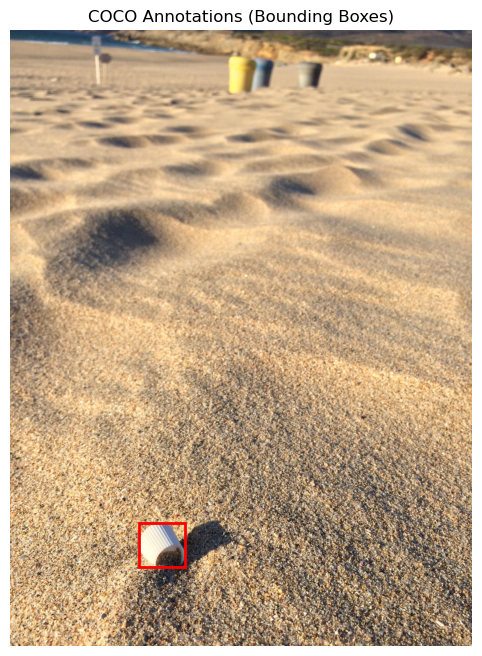

In [19]:
plt.figure(figsize=(8,8))
plt.imshow(img)
ax = plt.gca()

for ann in anns:
    x, y, w, h = ann['bbox']    # COCO bbox format
    rect = plt.Rectangle(
        (x, y), w, h,
        fill=False,
        edgecolor='red',
        linewidth=2
    )
    ax.add_patch(rect)

plt.axis("off")
plt.title("COCO Annotations (Bounding Boxes)")
plt.show()


In [25]:
# Count frequencies of all category IDs
cat_counts = {}
for ann in coco.dataset["annotations"]:
    cid = ann["category_id"]
    cat_counts[cid] = cat_counts.get(cid, 0) + 1

# Sorted by descending frequency
TOP_5_CAT_IDS = sorted(cat_counts, key=cat_counts.get, reverse=True)[:5]
print("TOP 5 CATEGORY IDS:", TOP_5_CAT_IDS)


TOP 5 CATEGORY IDS: [59, 58, 36, 5, 29]


In [27]:
# Restore TOP_5_CAT_IDS

# Build frequency dictionary of all categories
cat_counts = {}
for ann in coco.dataset["annotations"]:
    cid = ann["category_id"]
    cat_counts[cid] = cat_counts.get(cid, 0) + 1

# Get top 5 category IDs (COCO-style numeric category IDs)
TOP_5_CAT_IDS = sorted(cat_counts, key=cat_counts.get, reverse=True)[:5]

print("Restored TOP_5_CAT_IDS:", TOP_5_CAT_IDS)
print("Number of classes:", len(TOP_5_CAT_IDS) + 1)   # bg + classes


Restored TOP_5_CAT_IDS: [59, 58, 36, 5, 29]
Number of classes: 6


In [35]:
import os
import json
import torch
from pycocotools.coco import COCO

print("=== RESTORING PROJECT ENVIRONMENT ===")

# --------------------------
# DEVICE
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# --------------------------
# PROJECT BASE DIRECTORY
# (adjust if your base folder is different)
# --------------------------
BASE_DIR = r"E:\coding stuff (datasets)\taco trash dataset"
print("BASE_DIR:", BASE_DIR)


# --------------------------
# OUTPUT DIR (where CSVs, comparisons, unet weights were saved)
# --------------------------
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR)


# --------------------------
# YOLO DATA DIR (train/val labels + images)
# --------------------------
YOLO_DATA_DIR = os.path.join(BASE_DIR, "yolo_data")
print("YOLO_DATA_DIR:", YOLO_DATA_DIR)


# --------------------------
# RESTORE COCO ANNOTATIONS
# --------------------------
ANNOTATIONS_PATH = os.path.join(BASE_DIR, "data", "annotations.json")

print("Loading COCO dataset...")
coco = COCO(ANNOTATIONS_PATH)


# --------------------------
# REBUILD TOP_5_CAT_IDS (used by U-Net)
# --------------------------
cat_counts = {}
for ann in coco.dataset["annotations"]:
    cid = ann["category_id"]
    cat_counts[cid] = cat_counts.get(cid, 0) + 1

TOP_5_CAT_IDS = sorted(cat_counts, key=cat_counts.get, reverse=True)[:5]
print("TOP_5_CAT_IDS:", TOP_5_CAT_IDS)
print("num U-Net classes:", len(TOP_5_CAT_IDS) + 1)


print("\n=== RESTORATION COMPLETE ===")


=== RESTORING PROJECT ENVIRONMENT ===
Using device: cuda
BASE_DIR: E:\coding stuff (datasets)\taco trash dataset
OUTPUT_DIR: E:\coding stuff (datasets)\taco trash dataset\output
YOLO_DATA_DIR: E:\coding stuff (datasets)\taco trash dataset\yolo_data
Loading COCO dataset...
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
TOP_5_CAT_IDS: [59, 58, 36, 5, 29]
num U-Net classes: 6

=== RESTORATION COMPLETE ===


In [37]:
import torch
import torch.nn as nn

# -----------------------------
# U-NET ARCHITECTURE
# -----------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = DoubleConv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = DoubleConv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = DoubleConv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = DoubleConv(128, 64)

        self.conv_last = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b  = self.bottleneck(self.pool4(e4))

        d4 = self.upconv4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.conv_last(d1)

# -----------------------------
# CREATE & LOAD MODEL
# -----------------------------
num_classes = len(TOP_5_CAT_IDS) + 1  # bg + 5 categories
unet_model = UNet(num_classes=num_classes).to(device)

unet_best = os.path.join(OUTPUT_DIR, "unet_best.pth")

if os.path.exists(unet_best):
    state = torch.load(unet_best, map_location=device)
    unet_model.load_state_dict(state, strict=True)
    unet_model.eval()
    print("✅ U-Net weights loaded from:", unet_best)
else:
    print("❌ U-Net weights not found at:", unet_best)


✅ U-Net weights loaded from: E:\coding stuff (datasets)\taco trash dataset\output\unet_best.pth


In [41]:
import torch.nn as nn

# Device (reconfirm)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4    = DoubleConv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3    = DoubleConv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2    = DoubleConv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1    = DoubleConv(128, 64)

        self.conv_last = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b  = self.bottleneck(self.pool4(e4))

        d4 = self.upconv4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.conv_last(d1)

num_classes = len(TOP_5_CAT_IDS) + 1
unet_model = UNet(num_classes=num_classes).to(device)

unet_best = os.path.join(OUTPUT_DIR, "unet_best.pth")

if os.path.exists(unet_best):
    state = torch.load(unet_best, map_location=device)
    unet_model.load_state_dict(state, strict=True)
    unet_model.eval()
    print("✅ U-Net weights loaded from:", unet_best)
else:
    print("❌ U-Net weights NOT FOUND at:", unet_best)


Using device: cuda
✅ U-Net weights loaded from: E:\coding stuff (datasets)\taco trash dataset\output\unet_best.pth


In [ ]:
## Conclusion

YOLO provides effective object detection for identifying trash instances, while U-Net enables detailed segmentation at the pixel level.
Together, these approaches demonstrate complementary strengths for environmental perception tasks.